# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Sherlock Chen

**Date:** 9/6/2026

In [10]:
# Question 1.1
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path = "./data/airbnb_hw.csv"
df = pd.read_csv(path)

# Price is type string and also has commas for some values so remove commas and convert to numeric
print(df["Price"].dtype)
df["Price_Clean"] = pd.to_numeric(df["Price"].str.replace(",", "", regex=False), errors="coerce")

# Sort prices by ascending to make more clean and organized 
df = df.sort_values(by="Price_Clean", ascending=True)

# print total missing values
total_missing = df["Price_Clean"].isna().sum()
print(f"Total Missing: {total_missing}") 


str
Total Missing: 0


In [12]:
# Question 1.2
path = "./data/mn_police_use_of_force.csv"
df = pd.read_csv(path)

# Find proportion of "subject injury" missing by getting total null rows in the column and total rows
df["null_subject_injury"] = df["subject_injury"].isnull()
total_null = df["null_subject_injury"].sum()
total_rows = len(df)

# About 76% of the data is missing, which is a concern because the proportion is so high
proportion_null = total_null / total_rows
print(f"Proportion of Subject_Injury Null: {proportion_null}") 

# Imputate with the impute value of "missing"
impute_value = "missing"
df["imputated_subject_injury"] = df["subject_injury"].fillna(impute_value)

# After cross-tabulation, the pattern is that most of the data missing is from the force type of bodily force
# Other missing values (but not as many as bodily force) are mainly chemical irritant, taser, and maximal restraint technique
# This pattern may mean that these injuries from these force types are easier to hide and not reported making a lot of them missing
crosstab = pd.crosstab(df["imputated_subject_injury"], df["force_type"])
print(crosstab)

Proportion of Subject_Injury Null: 0.7619342359767892
force_type                Baton  Bodily Force  Chemical Irritant  Firearm  \
imputated_subject_injury                                                    
No                            0          1093                131        2   
Yes                           2          1286                 41        0   
missing                       2          7051               1421        0   

force_type                Gun Point Display  Improvised Weapon  Less Lethal  \
imputated_subject_injury                                                      
No                                       33                 34            0   
Yes                                      44                 40            0   
missing                                  27                 74           87   

force_type                Less Lethal Projectile  Maximal Restraint Technique  \
imputated_subject_injury                                                        
No

float64
Min Year: 0
Max Year: 2026


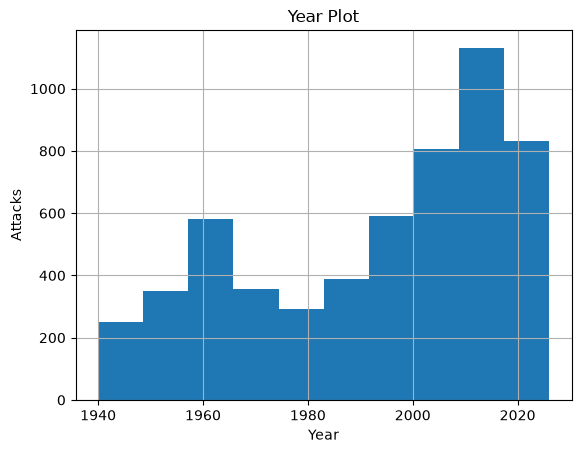

['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30'


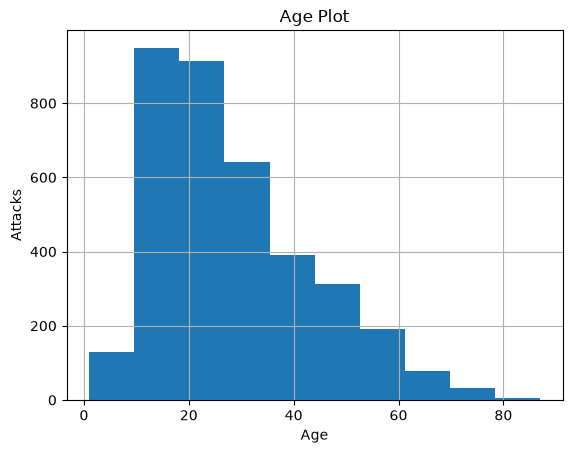

Male proportion: 0.8545808966861599
<StringArray>
[         'Unprovoked',            'Provoked',        'Questionable',
          'UNprovoked',          'unprovoked',           ' Provoked',
          'Watercraft',        'Sea Disaster',                   nan,
                   '?',         'Unconfirmed',          'Unverified',
             'Invalid', 'Under investigation',                'Boat']
Length: 15, dtype: str
str
Unprovoked Proportion: 0.7459236695932628


In [ ]:
# Question 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path = "./data/GSAF5.xls"
df = pd.read_excel(path)

# Drop columns that have no values at all
df = df.dropna(axis=1, how="all") 

# "Year" column type is float so convert to int
print(df["Year"].dtype)
df["Year_Clean"] = df["Year"].astype("Int64")

# The min year is 0 and max year is 2026
min_year = df["Year_Clean"].min()
max_year = df["Year_Clean"].max()
print(f"Min Year: {min_year}")
print(f"Max Year: {max_year}")

# Filter to only years since 1940 and create plot to see the trend
# According to the plot, the attacks are generally increasing over time
df = df[df["Year_Clean"] >= 1940]
df["Year_Clean"].hist()
plt.title("Year Plot")
plt.xlabel("Year")
plt.ylabel("Attacks")
plt.show()

# Age has strings inside it and also type object so convert to numeric
print(df["Age"].unique())
print(df["Age"].dtype)
df["Age_Clean"] = pd.to_numeric(df["Age"], errors="coerce")

# Create histogram of age
df["Age_Clean"].hist()
plt.title("Age Plot")
plt.xlabel("Age")
plt.ylabel("Attacks")
plt.show()

# About 85% of the victims are male
male_count = (df["Sex"] == "M").sum()
total_sex = df["Sex"].notna().sum()
male_proportion = male_count / total_sex
print(f"Male proportion: {male_proportion}")

# Values in "Type" column are have different capitalizations so make function to normalize capitalization and assign unknown to ones that don't fit any category
print(df["Type"].unique())
print(df["Type"].dtype)

def normalize_type(type_value):
    normalized_type_value = str(type_value).capitalize()

    if normalized_type_value == "Provoked":
        return "Provoked"
    elif normalized_type_value == "Unprovoked":
        return "Unprovoked"
    else:
        return "Unknown"

# Apply function to column and assign to clean column
df["Type_Clean"] = df["Type"].apply(normalize_type)

# The unprovoked proportion is about 75%
unprovoked_count = (df["Type_Clean"] == "Unprovoked").sum()
total_rows = len(df)
unprovoked_proportion = unprovoked_count / total_rows
print(f"Unprovoked Proportion: {unprovoked_proportion}")

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]